In [3]:
import xgi
import numpy as np
from had_model import HAD_model
import matplotlib.pyplot as plt

In [21]:
N = 300
ps = [1e-3, 1e-4, 1e-6]
seed = 0
H = xgi.fast_random_hypergraph(N, ps, seed=seed)
H.cleanup()
print(H)
xgi.unique_edge_sizes(H), xgi.is_connected(H)

Unnamed Hypergraph with 300 nodes and 791 hyperedges


([2, 3, 4], True)

In [23]:
epsilon = 0.05
Model = HAD_model(epsilon, H.edges.members())
T = 100
results = Model.simulate(T)

100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 217.63it/s]


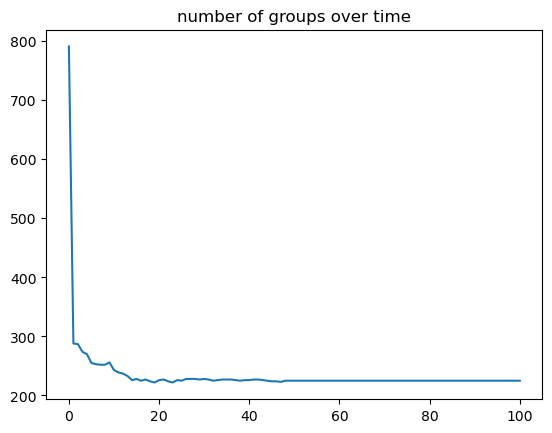

In [25]:
aa = [len(results['groups'][i]) for i in range(T+1)]

plt.plot(aa)
#plt.ylim()
plt.title('number of groups over time')
plt.show()

In [27]:
s_avg_t = []
for t in range(T+1):
    sizes_t = [len(group) for group in results['groups'][t]]
    s_avg_t.append(np.mean(sizes_t))

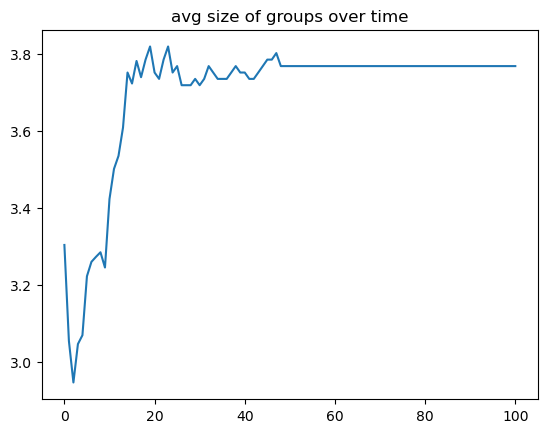

In [29]:
plt.plot(range(T+1), s_avg_t)
plt.title('avg size of groups over time')
plt.show()

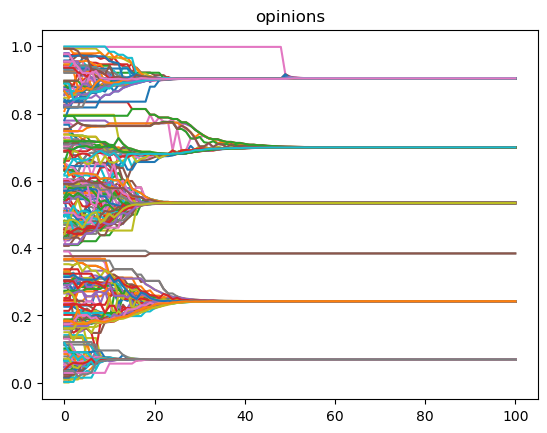

In [31]:
for n in H.nodes:
    plt.plot(results['opinions'][n])
plt.title('opinions')
plt.show()